# Stock Market Prediction

In [255]:
# Parameters
TICKER        = "AAPL"
FORECAST_DAYS = 10
LOOK_BACK     = 60
PERIOD        = "2y"
EPOCHS        = 50
BATCH_SIZE    = 32
DT_MAX_DEPTH  = 40

## Libraries

In [256]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

## Load Data

In [257]:
def load_data(ticker, period):
    tk = yf.Ticker(ticker)
    df = tk.history(period=period, interval="1d", auto_adjust=True)
    return df[["Close"]].dropna().values.reshape(-1, 1)

data = load_data(TICKER, PERIOD)
# print(data.head())

## Preprocessing

In [258]:
def data_preprocessing(data):
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(data)
    return scaled, scaler

scaled, scaler = data_preprocessing(data)
print(f"scaled shape: {scaled.shape}")

scaled shape: (501, 1)


## Sliding Windows

In [259]:
def make_windows(scaled, look_back):
    X, y = [], []
    for i in range(len(scaled) - look_back):
        X.append(scaled[i : i + look_back])
        y.append(scaled[i + look_back, 0])
    return np.array(X), np.array(y)

X, y = make_windows(scaled, LOOK_BACK)

## Split data

In [260]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print('X_train shape: ', X_train.shape)
print('X_test shape: ', X_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ', y_test.shape)

X_train shape:  (352, 60, 1)
X_test shape:  (89, 60, 1)
y_train shape:  (352,)
y_test shape:  (89,)


## LSTM Neural Network

### Model Building

In [261]:
def build_model(look_back):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(look_back, 1)),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1),
    ])
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae'],
    )
    return model

nn = build_model(LOOK_BACK)

### Model Training

In [262]:
nn.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
       validation_data=(X_test, y_test), verbose=1)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0901 - mae: 0.2412 - val_loss: 0.0103 - val_mae: 0.0857
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0110 - mae: 0.0815 - val_loss: 0.0207 - val_mae: 0.1268
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0071 - mae: 0.0664 - val_loss: 0.0062 - val_mae: 0.0612
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0046 - mae: 0.0512 - val_loss: 0.0051 - val_mae: 0.0565
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0038 - mae: 0.0473 - val_loss: 0.0060 - val_mae: 0.0610
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0036 - mae: 0.0448 - val_loss: 0.0043 - val_mae: 0.0534
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0032 - mae: 0.0423 - val_loss: 0.0042 - val_mae: 0.0532
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0031 - mae: 0.0411 - val_loss: 0.0039 - val_mae: 0.0517
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0030 - m

### Model Predictions

In [263]:
def predict_future_nn(model, last_window, scaler, n_days):
    window = last_window.copy()
    preds = []
    for _ in range(n_days):
        pred = model.predict(window.reshape(1, len(window), 1), verbose=0)[0, 0]
        preds.append(pred)
        window = np.append(window[1:], [[pred]], axis=0)
    return scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

nn_forecast = predict_future_nn(nn, X_test[-1], scaler, FORECAST_DAYS)
print("NN forecast:", np.round(nn_forecast, 2))

NN forecast: [296.25 296.17 295.87 295.38 294.68 293.82 292.84 291.74 290.56 289.31]


## Decision Tree

### Tree Building

In [264]:
def build_dt(dt_depth):
    model = DecisionTreeRegressor(max_depth=dt_depth, random_state=42)
    return model

dt = build_dt(DT_MAX_DEPTH)

### Tree Training

In [265]:
def train_dt(X_train, y_train):
    dt.fit(X_train.reshape(len(X_train), -1), y_train)
    return dt

dt = train_dt(X_train, y_train)

### Tree Predictions

In [266]:
def predict_future_dt(dt, last_window, scaler, n_days):
    window = last_window.copy()
    preds = []
    for _ in range(n_days):
        pred = dt.predict(window.reshape(1, -1))[0]
        preds.append(pred)
        window = np.append(window[1:], [[pred]], axis=0)
    return scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

print(f"DT R²  train: {dt.score(X_train.reshape(len(X_train),-1), y_train):.4f}  "
      f"test: {dt.score(X_test.reshape(len(X_test),-1), y_test):.4f}")

dt_forecast = predict_future_dt(dt, X_test[-1], scaler, FORECAST_DAYS)
print("DT forecast:", np.round(dt_forecast, 2))

DT R²  train: 1.0000  test: 0.5744
DT forecast: [273.6  273.16 274.1  274.1  274.1  274.1  274.1  274.1  274.1  274.1 ]


## Linear Regression

### Model Building

In [267]:
def build_lr():
    return LinearRegression()

lr = build_lr()

### Model Training

In [268]:
def train_lr(lr, X_train, y_train):
    lr.fit(X_train.reshape(len(X_train), -1), y_train)
    return lr

lr = train_lr(lr, X_train, y_train)

### Model Predictions

In [269]:
def predict_future_lr(lr, last_window, scaler, n_days):
    window = last_window.copy()
    preds = []
    for _ in range(n_days):
        pred = lr.predict(window.reshape(1, -1))[0]
        preds.append(pred)
        window = np.append(window[1:], [[pred]], axis=0)
    return scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

print(f"LR R²  train: {lr.score(X_train.reshape(len(X_train),-1), y_train):.4f}  "
      f"test: {lr.score(X_test.reshape(len(X_test),-1), y_test):.4f}")

lr_forecast = predict_future_lr(lr, X_test[-1], scaler, FORECAST_DAYS)
print("LR forecast:", np.round(lr_forecast, 2))

LR R²  train: 0.9761  test: 0.8505
LR forecast: [295.49 294.3  289.1  287.73 283.94 282.04 279.82 279.26 279.14 276.58]


## Results

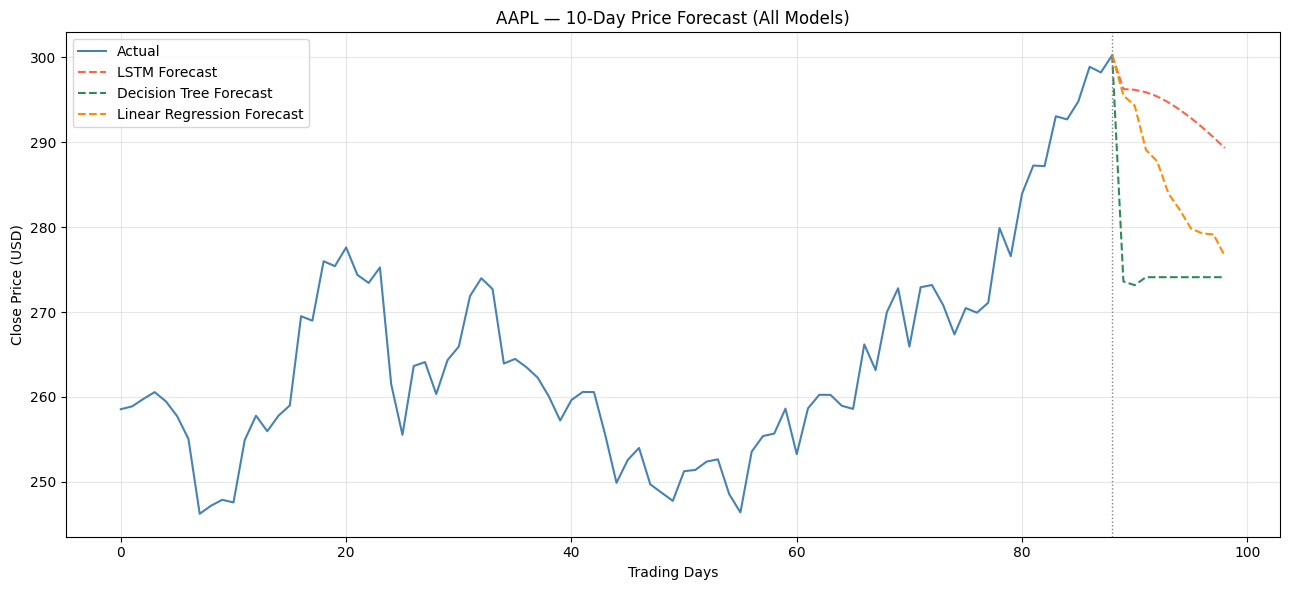

In [271]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(hist_x, actual, label='Actual', color='steelblue')
ax.plot(fore_x, np.concatenate([[actual[-1]], nn_forecast]),
        label='LSTM Forecast', color='tomato', linestyle='--')
ax.plot(fore_x, np.concatenate([[actual[-1]], dt_forecast]),
        label='Decision Tree Forecast', color='seagreen', linestyle='--')
ax.plot(fore_x, np.concatenate([[actual[-1]], lr_forecast]),
        label='Linear Regression Forecast', color='darkorange', linestyle='--')
ax.axvline(len(actual) - 1, color='gray', linestyle=':', linewidth=1)
ax.set_title(f'{TICKER} — {FORECAST_DAYS}-Day Price Forecast (All Models)')
ax.set_xlabel('Trading Days')
ax.set_ylabel('Close Price (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()